# VINSight Ford — Risco de evasão (churn) e segmentação dos clientes de pós-venda

**Challenge FIAP 2026 · Ford · Desafio 02 — Impulsionando o VIN Share na América do Sul**
Disciplina: Inteligência Artificial & Machine Learning · Grupo 02

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Challenge-2026-VinsightFord/vinsight-api/blob/master/ml/vinsight_churn.ipynb)

Este notebook produz a camada de inteligência do VINSight:

1. um **classificador** que dá a cada veículo a probabilidade de o cliente **sair da rede oficial** nos próximos 12 meses (o *score* de evasão);
2. um **agrupamento (K-Means)** que separa os clientes em perfis de comportamento (Fiel, Abandono, Esquecido, Econômico);
3. a **aplicação dos dois modelos na frota da demonstração**, gerando os leads no formato exato do `POST /api/v1/leads` da API.

O notebook roda do início ao fim sem configuração, localmente ou no Google Colab.

## 1. Compreensão do problema

**Problema de negócio.** O VIN Share é a porcentagem dos veículos Ford em circulação que fazem manutenção na rede oficial. Depois do fim da garantia, parte dos proprietários migra para oficinas independentes, e a concessionária só percebe a perda quando ela já aconteceu.

**Objetivo da solução.** Antecipar a evasão: estimar, para cada veículo, o risco de o cliente não voltar à rede, para que o consultor de serviço entre em contato primeiro com quem tem mais risco, com o motivo e a ação recomendada.

**Caracterização como problema de Machine Learning.**

| Tarefa | Tipo | Variável-alvo / saída |
|---|---|---|
| Score de evasão | **Classificação binária supervisionada** | `evadiu_12m` = 1 se o veículo **não fez nenhum serviço na rede** nos 12 meses seguintes à data de referência |
| Perfil do cliente | **Agrupamento não supervisionado** | Rótulo de negócio do cluster (Fiel, Abandono, Esquecido, Econômico) |

A saída usada pela aplicação é a **probabilidade** da classe 1, não só a classe: a API ordena a fila de leads pelo score.

**Dados.** A Ford não disponibiliza dados reais de clientes para o Challenge, então o treino usa uma **base sintética** (permitido pelo enunciado), gerada com regras de negócio de pós-venda descritas na seção 2. A aplicação final usa a **frota real da massa de demonstração da API** (37 veículos exportados do MySQL por `exportar_frota.sql`), com as mesmas colunas.

**Métrica principal: recall da classe "evadiu".** Deixar de abordar um cliente que vai sair custa a receita de serviço dos próximos anos e enfraquece a próxima venda; um contato a mais com um cliente que ficaria custa só uma ligação. Por isso o modelo é escolhido pelo **recall**, com uma precisão mínima aceitável, e o limiar de decisão é ajustado para isso (seção 5).

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, adjusted_rand_score, average_precision_score, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve,
                             silhouette_score)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold, cross_val_predict, cross_validate,
                                     train_test_split)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

SEMENTE = 42
DATA_REFERENCIA = pd.Timestamp("2026-10-08")  # "hoje" do modelo: só se usa o que se sabe até esta data
AZUL_FORD, AZUL_DESTAQUE, CINZA, VERMELHO = "#00095B", "#066FEF", "#9CA3AF", "#C0392B"

PASTA = Path(".")
SAIDA = PASTA / "saida"
SAIDA.mkdir(exist_ok=True)
URL_FROTA = "https://raw.githubusercontent.com/Challenge-2026-VinsightFord/vinsight-api/master/ml/dados/frota_demo.csv"

## 2. Base de treino sintética

Cada veículo sintético pertence a um **perfil oculto de comportamento**, e o perfil define como ele usa a rede. É assim que a base ganha estrutura realista: o classificador precisa aprender o risco **a partir das variáveis observáveis**, sem ver o perfil, e o K-Means precisa redescobrir os perfis sem rótulo nenhum.

| Perfil oculto | Proporção | Comportamento |
|---|---|---|
| Fiel | 35% | Quase todos os serviços na rede, revisão em dia, NPS alto |
| Econômico | 25% | Muitos serviços, ticket baixo, divide entre rede e oficina independente |
| Esquecido | 20% | Poucos serviços, revisão atrasada, raramente responde NPS |
| Abandono | 20% | Último serviço na rede há muito tempo, continua fazendo serviço fora |

O alvo `evadiu_12m` é sorteado de uma probabilidade que combina fatores conhecidos de pós-venda (garantia encerrada, tempo sem serviço na rede, aderência à rede, NPS, revisão vencida, alerta de falha na telemetria, idade do veículo), com ruído para que nenhum fator decida sozinho.

A base tem as **mesmas colunas** da exportação da frota real (`exportar_frota.sql`), então a mesma função de preparação serve ao treino e à aplicação. E ela já vem com **problemas de qualidade** comuns em dado de concessionária, para serem tratados na seção 3: NPS ausente, quilometragem ausente e quilometragem digitada errada (um zero a mais).

In [2]:
def gerar_base_sintetica(n=8000, semente=SEMENTE):
    rng = np.random.default_rng(semente)
    perfis = rng.choice(["FIEL", "ECONOMICO", "ESQUECIDO", "ABANDONO"], size=n, p=[0.35, 0.25, 0.20, 0.20])
    modelos = ["Ranger", "Territory", "Bronco Sport", "Maverick", "Mustang Mach-E", "Ka", "EcoSport"]

    # Parâmetros por perfil: aderência à rede, meses desde o último serviço, frequência e ticket
    aderencia_media = {"FIEL": 0.92, "ECONOMICO": 0.55, "ESQUECIDO": 0.60, "ABANDONO": 0.18}
    meses_sem_servico = {"FIEL": (1, 7), "ECONOMICO": (1, 6), "ESQUECIDO": (14, 36), "ABANDONO": (1, 8)}
    servicos_ano = {"FIEL": 1.8, "ECONOMICO": 2.4, "ESQUECIDO": 0.7, "ABANDONO": 1.6}
    ticket = {"FIEL": 1450, "ECONOMICO": 750, "ESQUECIDO": 1300, "ABANDONO": 1100}
    nps = {"FIEL": (8.6, 1.0), "ECONOMICO": (7.2, 1.3), "ESQUECIDO": (6.8, 1.6), "ABANDONO": (5.2, 1.6)}
    nps_ausente = {"FIEL": 0.20, "ECONOMICO": 0.30, "ESQUECIDO": 0.60, "ABANDONO": 0.35}
    risco_base = {"FIEL": -1.6, "ECONOMICO": -0.2, "ESQUECIDO": 0.3, "ABANDONO": 1.0}

    linhas = []
    for i, p in enumerate(perfis):
        idade_meses = int(rng.integers(3, 97))
        data_compra = DATA_REFERENCIA - pd.DateOffset(months=idade_meses) - pd.Timedelta(days=int(rng.integers(0, 28)))
        km_ano = float(np.clip(rng.normal(15000, 4500), 5000, 35000))
        km = km_ano * idade_meses / 12

        os_total = int(rng.poisson(servicos_ano[p] * max(idade_meses, 6) / 12))
        aderencia = float(np.clip(rng.normal(aderencia_media[p], 0.12), 0, 1))
        os_na_rede = int(rng.binomial(os_total, aderencia)) if os_total else 0

        sem_servico = float(rng.uniform(*meses_sem_servico[p]))
        ultimo_servico = DATA_REFERENCIA - pd.Timedelta(days=int(sem_servico * 30.4)) if os_total else pd.NaT
        if os_na_rede:
            # Abandono: o último serviço NA REDE ficou para trás, mesmo com serviço recente fora dela
            atraso_rede = rng.uniform(14, 44) if p == "ABANDONO" else rng.uniform(0, 5)
            ultimo_servico_rede = ultimo_servico - pd.Timedelta(days=int(atraso_rede * 30.4))
        else:
            ultimo_servico_rede = pd.NaT

        base_revisao = ultimo_servico_rede if pd.notna(ultimo_servico_rede) else data_compra
        proxima_revisao_data = base_revisao + pd.Timedelta(days=365)
        proxima_revisao_km = int(np.ceil((km + 1) / 10000) * 10000)
        falhas = ",".join(rng.choice(["P0420", "P0301", "P0171", "P0128", "P0442"], size=int(rng.integers(1, 3)),
                                     replace=False)) if rng.random() < 0.15 else np.nan
        canal = rng.choice(["EMAIL", "TELEFONE", "WHATSAPP"], p=[0.35, 0.30, 0.35])
        nota = np.nan if rng.random() < nps_ausente[p] else float(np.clip(round(rng.normal(*nps[p])), 0, 10))

        linhas.append({
            "veiculo_id": i + 1, "cliente_id": i + 1, "vin": f"SINT{i + 1:013d}",
            "modelo": rng.choice(modelos, p=[0.22, 0.14, 0.14, 0.14, 0.10, 0.13, 0.13]),
            "ano_modelo": data_compra.year + int(rng.random() < 0.4),
            "data_compra": data_compra.normalize(),
            "km_estimada": round(km),
            "garantia_data_limite": (data_compra + pd.DateOffset(years=3)).normalize(),
            "proxima_revisao_data": proxima_revisao_data.normalize(),
            "proxima_revisao_km": proxima_revisao_km,
            "telemetria_codigos_falha": falhas,
            "ultimo_nps": nota,
            "canal_preferido": canal,
            "opt_in_whats_app": int(canal == "WHATSAPP" or rng.random() < 0.2),
            "consentimento_ativo": int(rng.random() < 0.88),
            "os_total": os_total, "os_na_rede": os_na_rede,
            "ultimo_servico": ultimo_servico.normalize() if pd.notna(ultimo_servico) else pd.NaT,
            "ultimo_servico_rede": ultimo_servico_rede.normalize() if pd.notna(ultimo_servico_rede) else pd.NaT,
            "ticket_medio": round(float(rng.lognormal(np.log(ticket[p]), 0.25)), 2) if os_total else np.nan,
            "perfil_oculto": p,
        })
    df = pd.DataFrame(linhas)

    # Probabilidade de evasão: fatores de negócio + ruído (o modelo nunca vê esta fórmula)
    garantia_vencida = (df["garantia_data_limite"] < DATA_REFERENCIA).astype(int)
    meses_sem_rede = ((DATA_REFERENCIA - df["ultimo_servico_rede"]).dt.days / 30.4).fillna(60).clip(0, 60)
    aderencia_obs = (df["os_na_rede"] / df["os_total"].replace(0, np.nan)).fillna(0)
    nps_obs = df["ultimo_nps"]
    revisao_vencida = (df["proxima_revisao_data"] < DATA_REFERENCIA).astype(int)
    tem_falha = df["telemetria_codigos_falha"].notna().astype(int)
    idade = (DATA_REFERENCIA - df["data_compra"]).dt.days / 30.4
    logito = (df["perfil_oculto"].map(risco_base) - 1.8
              + 0.9 * garantia_vencida
              + 0.045 * meses_sem_rede
              - 1.2 * aderencia_obs
              - 0.22 * (nps_obs.fillna(7) - 7)
              + 0.35 * nps_obs.isna()
              + 0.45 * revisao_vencida
              - 0.6 * tem_falha                                    # alerta de falha traz o cliente de volta
              + 0.4 * (idade > 60)
              + 0.6 * ((nps_obs <= 6) & (garantia_vencida == 1))   # insatisfeito e sem garantia
              - 0.25 * df["opt_in_whats_app"]
              + rng.normal(0, 0.6, n))
    df["evadiu_12m"] = (rng.random(n) < 1 / (1 + np.exp(-logito))).astype(int)

    # Problemas de qualidade típicos de cadastro
    ausente_km = rng.random(n) < 0.02
    df.loc[ausente_km, "km_estimada"] = np.nan
    digitado_errado = (~ausente_km) & (rng.random(n) < 0.01)
    df.loc[digitado_errado, "km_estimada"] = df.loc[digitado_errado, "km_estimada"] * 10
    return df


base = gerar_base_sintetica()
print(f"{len(base)} veículos sintéticos | taxa de evasão: {base['evadiu_12m'].mean():.1%}")
base.head()

8000 veículos sintéticos | taxa de evasão: 37.8%


,veiculo_id,cliente_id,vin,modelo,ano_modelo,data_compra,km_estimada,garantia_data_limite,proxima_revisao_data,proxima_revisao_km,telemetria_codigos_falha,ultimo_nps,canal_preferido,opt_in_whats_app,consentimento_ativo,os_total,os_na_rede,ultimo_servico,ultimo_servico_rede,ticket_medio,perfil_oculto,evadiu_12m
0,1,1,SINT0000000000001,Ranger,2019,2018-09-23,134113.0,2021-09-23,2025-02-16,140000,NaN,NaN,WHATSAPP,1,1,4,2,2024-07-12,2024-02-17,1933.29,ESQUECIDO,0
1,2,2,SINT0000000000002,Ranger,2024,2024-03-30,37408.0,2027-03-30,2027-01-16,40000,NaN,7.0,TELEFONE,0,1,5,2,2026-04-15,2026-01-16,943.50,ECONOMICO,1
2,3,3,SINT0000000000003,EcoSport,2024,2024-10-16,33724.0,2027-10-16,2024-06-22,40000,NaN,7.0,WHATSAPP,1,1,4,4,2026-05-14,2023-06-23,1005.24,ABANDONO,0
3,4,4,SINT0000000000004,EcoSport,2019,2019-07-20,NaN,2022-07-20,2024-08-19,110000,NaN,NaN,EMAIL,1,1,6,5,2023-10-23,2023-08-20,974.19,ESQUECIDO,1
4,5,5,SINT0000000000005,EcoSport,2022,2021-07-12,63173.0,2024-07-12,2027-02-22,70000,P0442,8.0,EMAIL,1,1,8,8,2026-07-22,2026-02-22,769.09,FIEL,0


## 3. Preparação dos dados

### 3.1 Análise exploratória

Valores ausentes por coluna (%):


,% ausente
km_estimada,1.8
telemetria_codigos_falha,85.0
ultimo_nps,33.3
ultimo_servico,6.2
ultimo_servico_rede,18.0
ticket_medio,6.2


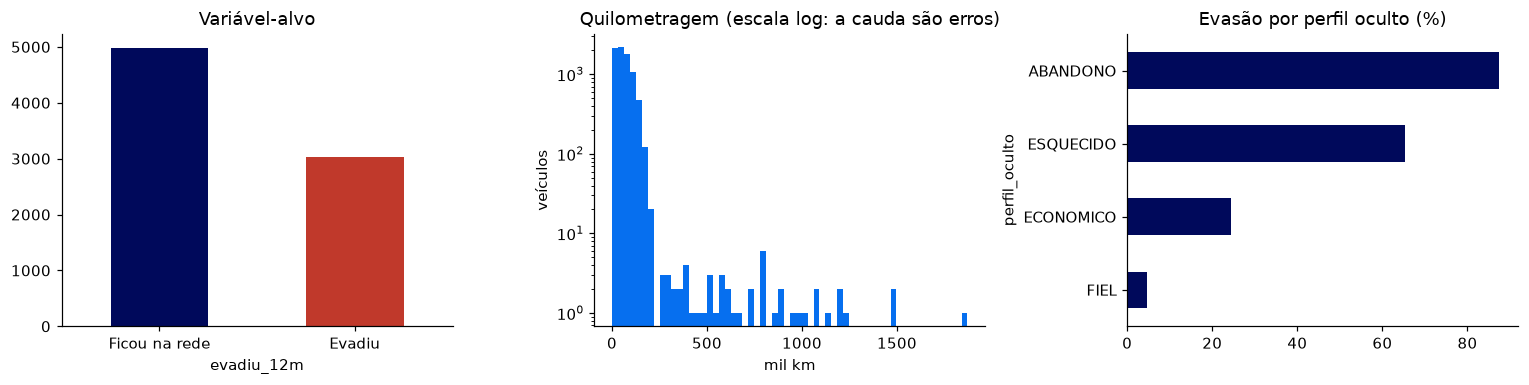

In [3]:
print("Valores ausentes por coluna (%):")
display((base.isna().mean() * 100).round(1)[lambda s: s > 0].to_frame("% ausente"))

fig, eixos = plt.subplots(1, 3, figsize=(14, 3.6))
base["evadiu_12m"].map({0: "Ficou na rede", 1: "Evadiu"}).value_counts().plot.bar(
    ax=eixos[0], color=[AZUL_FORD, VERMELHO], rot=0, title="Variável-alvo")
eixos[1].hist(base["km_estimada"].dropna() / 1000, bins=60, color=AZUL_DESTAQUE)
eixos[1].set_yscale("log")
eixos[1].set(title="Quilometragem (escala log: a cauda são erros)", xlabel="mil km", ylabel="veículos")
(base.groupby("perfil_oculto")["evadiu_12m"].mean() * 100).sort_values().plot.barh(
    ax=eixos[2], color=AZUL_FORD, title="Evasão por perfil oculto (%)")
plt.tight_layout()
plt.show()

O alvo é **moderadamente desbalanceado** (as evasões são a minoria), por isso a divisão de treino e teste é estratificada e os modelos usam `class_weight="balanced"` quando o algoritmo permite.

O histograma da quilometragem mostra uma cauda impossível para carro de passeio: são os **erros de digitação** (um zero a mais).

### 3.2 Tratamento e criação de variáveis

A função `preparar` transforma o cadastro bruto em variáveis do modelo. É **a mesma função** para o treino e para a frota real, o que evita diferença entre treino e produção.

| Problema / variável | Decisão | Justificativa |
|---|---|---|
| Quilometragem acima de 60.000 km/ano | Vira ausente e é imputada | Fisicamente implausível para uso de passeio: é erro de cadastro, não um cliente diferente |
| Quilometragem ausente | Mediana (no pipeline) | Poucos casos; a mediana é robusta à cauda |
| NPS ausente | Indicador `nps_ausente` + mediana | Não responder pesquisa **é informação** (cliente desengajado) |
| Nunca fez serviço na rede | `meses_sem_servico_rede` = 72 | "Nunca" é pior que qualquer atraso observado |
| Ticket médio | Limitado ao intervalo 200 a 6.000 | Winsorização em limites de negócio fixos (sem olhar o conjunto de teste) |
| Variáveis derivadas | Idade, meses de garantia restantes, aderência à rede, revisão vencida, falhas ativas, serviços por ano | Traduzem o histórico em sinais de risco que o consultor também entenderia |
| Categóricas | One-hot (`modelo`, `canal_preferido`) | Sem ordem natural |
| Escala | Padronização (média 0, desvio 1) | Necessária para Regressão Logística, MLP e K-Means |

**Sem vazamento de informação**: todas as variáveis são calculadas com o que se sabe até a `DATA_REFERENCIA`. O alvo olha para os 12 meses seguintes, e nenhuma variável usa informação desse período. O perfil oculto e os ids nunca entram no modelo.

In [4]:
NUMERICAS = ["idade_meses", "km_estimada", "km_por_ano", "meses_garantia", "garantia_vencida",
             "dias_para_revisao", "revisao_vencida", "qtd_falhas", "os_total", "aderencia_rede",
             "meses_sem_servico", "meses_sem_servico_rede", "os_por_ano", "ticket_medio",
             "nps", "nps_ausente", "opt_in_whats_app"]
CATEGORICAS = ["modelo", "canal_preferido"]


def meses_entre(inicio, fim):
    return (fim - inicio).dt.days / 30.4


def preparar(bruto, referencia=DATA_REFERENCIA):
    d = bruto.copy()
    for col in ["data_compra", "garantia_data_limite", "proxima_revisao_data", "ultimo_servico", "ultimo_servico_rede"]:
        d[col] = pd.to_datetime(d[col])
    x = pd.DataFrame(index=d.index)
    x["idade_meses"] = meses_entre(d["data_compra"], referencia)
    anos = (x["idade_meses"] / 12).clip(lower=0.25)
    km = d["km_estimada"].astype(float)
    km[(km / anos) > 60000] = np.nan                      # erro de digitação -> ausente
    x["km_estimada"] = km
    x["km_por_ano"] = km / anos
    x["meses_garantia"] = meses_entre(referencia, d["garantia_data_limite"])
    x["garantia_vencida"] = (x["meses_garantia"] < 0).astype(int)
    x["dias_para_revisao"] = (d["proxima_revisao_data"] - referencia).dt.days
    x["revisao_vencida"] = ((x["dias_para_revisao"] < 0) | (km >= d["proxima_revisao_km"])).astype(int)
    x["qtd_falhas"] = d["telemetria_codigos_falha"].fillna("").str.split(",").map(lambda c: len([v for v in c if v]))
    x["os_total"] = d["os_total"]
    x["aderencia_rede"] = (d["os_na_rede"] / d["os_total"].replace(0, np.nan)).fillna(0)
    x["meses_sem_servico"] = meses_entre(d["ultimo_servico"], referencia).fillna(72).clip(0, 72)
    x["meses_sem_servico_rede"] = meses_entre(d["ultimo_servico_rede"], referencia).fillna(72).clip(0, 72)
    x["os_por_ano"] = d["os_total"] / anos
    x["ticket_medio"] = d["ticket_medio"].clip(200, 6000)
    x["nps"] = d["ultimo_nps"]
    x["nps_ausente"] = d["ultimo_nps"].isna().astype(int)
    x["opt_in_whats_app"] = d["opt_in_whats_app"].astype(int)
    x["modelo"] = d["modelo"]
    x["canal_preferido"] = d["canal_preferido"]
    return x


X = preparar(base)
y = base["evadiu_12m"]
print(f"Quilometragens descartadas como erro de digitação: {(X['km_estimada'].isna().sum() - base['km_estimada'].isna().sum())}")
X.describe().T.round(2)

Quilometragens descartadas como erro de digitação: 59


,count,mean,std,min,25%,50%,75%,max
idade_meses,8000.0,50.49,27.16,3.03,26.91,50.82,73.85,97.01
km_estimada,7796.0,62742.24,40191.65,1250.00,29817.75,57421.50,89860.50,217708.00
km_por_ano,7796.0,14790.15,4493.61,4235.00,11690.07,14765.11,17784.72,47970.84
meses_garantia,8000.0,-14.45,27.16,-60.95,-37.83,-14.77,9.11,33.03
garantia_vencida,8000.0,0.66,0.47,0.00,0.00,1.00,1.00,1.00
dias_para_revisao,8000.0,-138.68,498.59,-2578.00,-396.25,109.00,190.00,332.00
revisao_vencida,8000.0,0.37,0.48,0.00,0.00,0.00,1.00,1.00
qtd_falhas,8000.0,0.23,0.57,0.00,0.00,0.00,0.00,2.00
os_total,8000.0,7.14,5.46,0.00,3.00,6.00,11.00,31.00
aderencia_rede,8000.0,0.58,0.37,0.00,0.25,0.62,1.00,1.00


In [5]:
pre_processamento = ColumnTransformer([
    ("num", Pipeline([("imputar", SimpleImputer(strategy="median")), ("padronizar", StandardScaler())]), NUMERICAS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAS),
])

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEMENTE)
print(f"Treino: {len(X_treino)} | Teste: {len(X_teste)} | evasão no treino {y_treino.mean():.1%}, no teste {y_teste.mean():.1%}")

Treino: 6400 | Teste: 1600 | evasão no treino 37.8%, no teste 37.8%


A imputação e a padronização ficam **dentro do pipeline**, então são aprendidas só com o treino de cada dobra da validação cruzada, sem olhar o teste.

## 4. Desenvolvimento dos modelos

Quatro algoritmos vistos em aula, todos com o mesmo pré-processamento e a mesma partição:

| Modelo | Por que entra na comparação |
|---|---|
| **Regressão Logística** | Linha de base interpretável: cada coeficiente é um efeito explicável ao negócio |
| **Random Forest** | Captura interações (ex.: NPS baixo *e* garantia vencida) sem engenharia manual |
| **Gradient Boosting** (HistGradientBoosting) | Costuma ser o mais forte em dados tabulares; rápido e lida bem com escalas diferentes |
| **Rede neural MLP** | Modelo não linear genérico; verifica se uma rede traz ganho sobre os modelos de árvore |

Avaliação por **validação cruzada estratificada de 5 dobras** no treino. O desvio entre dobras mostra a estabilidade de cada modelo.

In [6]:
def pipeline(modelo):
    return Pipeline([("pre", pre_processamento), ("modelo", modelo)])


candidatos = {
    "Regressão Logística": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced",
                                            n_jobs=-1, random_state=SEMENTE),
    "Gradient Boosting": HistGradientBoostingClassifier(class_weight="balanced", random_state=SEMENTE),
    "Rede neural (MLP)": MLPClassifier(hidden_layer_sizes=(32, 16), alpha=1e-3, max_iter=800,
                                       early_stopping=True, random_state=SEMENTE),
}
METRICAS = {"recall": "recall", "precisao": "precision", "f1": "f1", "roc_auc": "roc_auc", "pr_auc": "average_precision"}
dobras = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)

resultados_cv = {}
for nome, modelo in candidatos.items():
    r = cross_validate(pipeline(modelo), X_treino, y_treino, cv=dobras, scoring=METRICAS, n_jobs=-1)
    resultados_cv[nome] = {m: (r[f"test_{m}"].mean(), r[f"test_{m}"].std()) for m in METRICAS}

tabela_cv = pd.DataFrame({nome: {m: f"{media:.3f} ± {desvio:.3f}" for m, (media, desvio) in res.items()}
                          for nome, res in resultados_cv.items()}).T
tabela_cv

,recall,precisao,f1,roc_auc,pr_auc
Regressão Logística,0.830 ± 0.014,0.770 ± 0.016,0.799 ± 0.010,0.912 ± 0.008,0.862 ± 0.015
Random Forest,0.830 ± 0.022,0.766 ± 0.020,0.796 ± 0.014,0.907 ± 0.010,0.851 ± 0.016
Gradient Boosting,0.818 ± 0.016,0.757 ± 0.011,0.787 ± 0.008,0.904 ± 0.008,0.847 ± 0.015
Rede neural (MLP),0.780 ± 0.010,0.798 ± 0.021,0.788 ± 0.010,0.909 ± 0.007,0.859 ± 0.012


### 4.1 Ajuste de hiperparâmetros dos dois melhores

Os dois candidatos com maior **PR-AUC** (área sob a curva precisão-recall, a métrica mais informativa com classes desbalanceadas) passam por busca aleatória de hiperparâmetros, também com validação cruzada de 5 dobras.

In [7]:
espacos = {
    "Regressão Logística": {"modelo__C": np.logspace(-2, 1.5, 20)},
    "Random Forest": {"modelo__n_estimators": [200, 300, 500], "modelo__max_depth": [None, 8, 12, 16],
                      "modelo__min_samples_leaf": [2, 5, 10, 20], "modelo__max_features": ["sqrt", 0.5]},
    "Gradient Boosting": {"modelo__learning_rate": [0.03, 0.05, 0.08, 0.12], "modelo__max_iter": [150, 250, 400],
                          "modelo__max_leaf_nodes": [15, 31, 63], "modelo__min_samples_leaf": [20, 40, 80],
                          "modelo__l2_regularization": [0.0, 0.1, 1.0]},
    "Rede neural (MLP)": {"modelo__hidden_layer_sizes": [(16,), (32, 16), (64, 32)],
                          "modelo__alpha": np.logspace(-4, -1, 10), "modelo__learning_rate_init": [1e-3, 3e-3]},
}
dois_melhores = sorted(resultados_cv, key=lambda n: resultados_cv[n]["pr_auc"][0], reverse=True)[:2]
print("Ajustando:", dois_melhores)

ajustados = {}
for nome in dois_melhores:
    busca = RandomizedSearchCV(pipeline(candidatos[nome]), espacos[nome], n_iter=12, scoring="average_precision",
                               cv=dobras, random_state=SEMENTE, n_jobs=-1)
    busca.fit(X_treino, y_treino)
    ajustados[nome] = busca.best_estimator_
    original = resultados_cv[nome]["pr_auc"][0]
    print(f"{nome}: PR-AUC {original:.3f} -> {busca.best_score_:.3f} | {busca.best_params_}")

Ajustando: ['Regressão Logística', 'Rede neural (MLP)']


Regressão Logística: PR-AUC 0.862 -> 0.862 | {'modelo__C': np.float64(0.08337822234717891)}


Rede neural (MLP): PR-AUC 0.859 -> 0.860 | {'modelo__learning_rate_init': 0.003, 'modelo__hidden_layer_sizes': (32, 16), 'modelo__alpha': np.float64(0.1)}


## 5. Avaliação e comparação

### 5.1 Limiar de decisão

Com o limiar padrão de 0,5, o modelo não necessariamente atinge o recall que o negócio precisa. Para cada candidato ajustado, o limiar é escolhido nas **previsões fora da dobra** (validação cruzada no treino, nunca no teste) como o que dá a **maior precisão com recall de pelo menos 80%**. O modelo final é o que tem a melhor precisão nessa condição: entre dois modelos que encontram 80% dos clientes em evasão, vence o que desperdiça menos ligações.

In [8]:
RECALL_MINIMO = 0.80


def limiar_para_recall(y_real, probabilidade, recall_minimo=RECALL_MINIMO):
    precisao, recall, limiares = precision_recall_curve(y_real, probabilidade)
    validos = np.where(recall[:-1] >= recall_minimo)[0]
    melhor = validos[np.argmax(precisao[validos])]
    return limiares[melhor], precisao[melhor], recall[melhor]


escolha = {}
for nome, modelo in ajustados.items():
    oof = cross_val_predict(modelo, X_treino, y_treino, cv=dobras, method="predict_proba", n_jobs=-1)[:, 1]
    limiar, precisao, recall = limiar_para_recall(y_treino, oof)
    escolha[nome] = (limiar, precisao, recall)
    print(f"{nome}: limiar {limiar:.3f} -> precisão {precisao:.3f} com recall {recall:.3f} (validação)")

NOME_FINAL = max(escolha, key=lambda n: escolha[n][1])
LIMIAR = float(escolha[NOME_FINAL][0])
print(f"\nModelo selecionado: {NOME_FINAL} (limiar {LIMIAR:.3f})")

Regressão Logística: limiar 0.566 -> precisão 0.789 com recall 0.801 (validação)


Rede neural (MLP): limiar 0.456 -> precisão 0.783 com recall 0.800 (validação)

Modelo selecionado: Regressão Logística (limiar 0.566)


### 5.2 Desempenho no conjunto de teste

O teste (20% da base, nunca usado em nenhuma decisão até aqui) mede o desempenho esperado em dados novos. A tabela traz os quatro modelos com os hiperparâmetros padrão e limiar 0,5, para comparação, e o modelo final ajustado com o limiar de negócio.

In [9]:
def avaliar(nome, modelo, limiar=0.5):
    p = modelo.predict_proba(X_teste)[:, 1]
    previsto = (p >= limiar).astype(int)
    return {"modelo": nome, "limiar": round(limiar, 3), "recall": recall_score(y_teste, previsto),
            "precisao": precision_score(y_teste, previsto), "f1": f1_score(y_teste, previsto),
            "roc_auc": roc_auc_score(y_teste, p), "pr_auc": average_precision_score(y_teste, p)}, p


linhas, probabilidades = [], {}
for nome, modelo in candidatos.items():
    ajustado_base = pipeline(modelo).fit(X_treino, y_treino)
    metricas, probabilidades[nome] = avaliar(nome, ajustado_base)
    linhas.append(metricas)

modelo_final = ajustados[NOME_FINAL]
metricas_finais, prob_final = avaliar(f"{NOME_FINAL} (ajustado, limiar de negócio)", modelo_final, LIMIAR)
linhas.append(metricas_finais)
comparacao = pd.DataFrame(linhas).set_index("modelo").round(3)
comparacao

,limiar,recall,precisao,f1,roc_auc,pr_auc
modelo,,,,,,
Regressão Logística,0.500,0.808,0.762,0.785,0.903,0.840
Random Forest,0.500,0.810,0.758,0.783,0.899,0.831
Gradient Boosting,0.500,0.821,0.761,0.790,0.899,0.822
Rede neural (MLP),0.500,0.755,0.778,0.766,0.882,0.812
"Regressão Logística (ajustado, limiar de negócio)",0.566,0.788,0.787,0.787,0.903,0.839


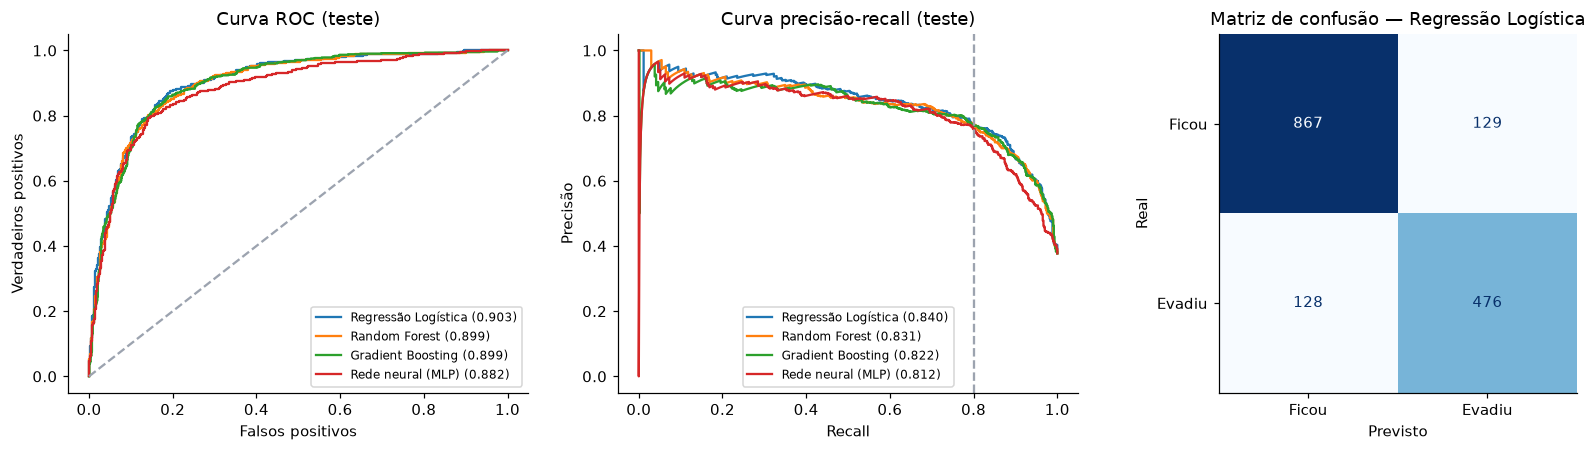

In [10]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4.2))
for nome, p in probabilidades.items():
    fpr, tpr, _ = roc_curve(y_teste, p)
    eixos[0].plot(fpr, tpr, label=f"{nome} ({roc_auc_score(y_teste, p):.3f})")
    pr, rc, _ = precision_recall_curve(y_teste, p)
    eixos[1].plot(rc, pr, label=f"{nome} ({average_precision_score(y_teste, p):.3f})")
eixos[0].plot([0, 1], [0, 1], "--", color=CINZA)
eixos[0].set(title="Curva ROC (teste)", xlabel="Falsos positivos", ylabel="Verdadeiros positivos")
eixos[1].axvline(RECALL_MINIMO, ls="--", color=CINZA)
eixos[1].set(title="Curva precisão-recall (teste)", xlabel="Recall", ylabel="Precisão")
eixos[0].legend(fontsize=8)
eixos[1].legend(fontsize=8)
ConfusionMatrixDisplay.from_predictions(y_teste, (prob_final >= LIMIAR).astype(int), ax=eixos[2], colorbar=False,
                                        display_labels=["Ficou", "Evadiu"], cmap="Blues")
eixos[2].set(title=f"Matriz de confusão — {NOME_FINAL}", xlabel="Previsto", ylabel="Real")
plt.tight_layout()
plt.savefig(SAIDA / "avaliacao_modelos.png", bbox_inches="tight")
plt.show()

### 5.3 Valor para a concessionária: quantas evasões a fila encontra

Na prática, o consultor liga de cima para baixo na fila ordenada pelo score. A curva abaixo mostra que fração das evasões é encontrada contatando os X% de maior risco da frota, comparada com ligar ao acaso.

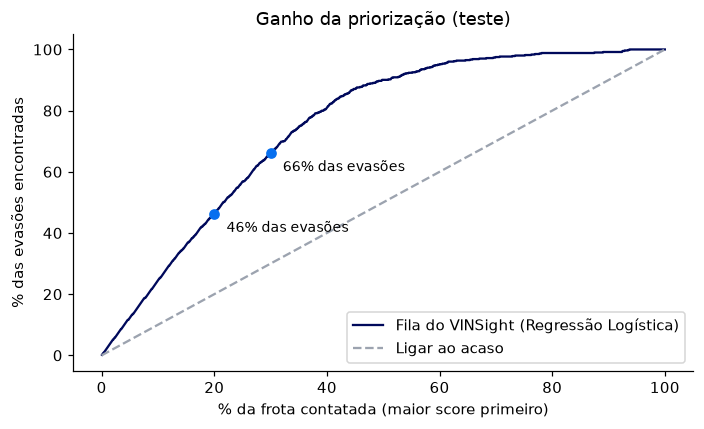

Contatando os 30% de maior score, o consultor encontra 66% das evasões (ao acaso: 30%).


In [11]:
ordem = np.argsort(-prob_final)
capturadas = np.cumsum(y_teste.to_numpy()[ordem]) / y_teste.sum()
fracao_frota = np.arange(1, len(ordem) + 1) / len(ordem)
fig, eixo = plt.subplots(figsize=(6.5, 4))
eixo.plot(fracao_frota * 100, capturadas * 100, color=AZUL_FORD, label=f"Fila do VINSight ({NOME_FINAL})")
eixo.plot([0, 100], [0, 100], "--", color=CINZA, label="Ligar ao acaso")
for corte in (0.2, 0.3):
    i = int(corte * len(ordem)) - 1
    eixo.scatter(corte * 100, capturadas[i] * 100, color=AZUL_DESTAQUE, zorder=3)
    eixo.annotate(f"{capturadas[i]:.0%} das evasões", (corte * 100, capturadas[i] * 100),
                  textcoords="offset points", xytext=(8, -12), fontsize=9)
eixo.set(xlabel="% da frota contatada (maior score primeiro)", ylabel="% das evasões encontradas",
         title="Ganho da priorização (teste)")
eixo.legend()
plt.tight_layout()
plt.savefig(SAIDA / "ganho_priorizacao.png", bbox_inches="tight")
plt.show()
CAPTURA_30 = capturadas[int(0.3 * len(ordem)) - 1]
print(f"Contatando os 30% de maior score, o consultor encontra {CAPTURA_30:.0%} das evasões (ao acaso: 30%).")

### 5.4 O que pesa no score

Importância por permutação no teste: quanto a PR-AUC cai quando os valores de uma variável são embaralhados. Ela é calculada sobre as variáveis de entrada, antes do one-hot, então os nomes são os do negócio.

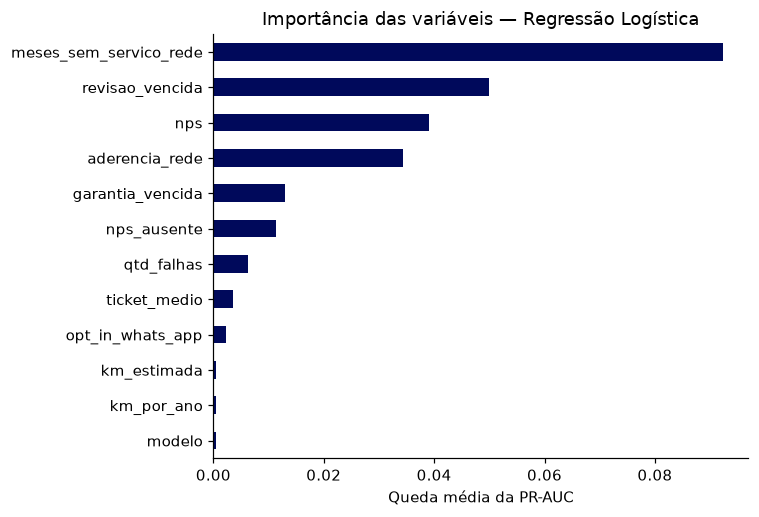

In [12]:
importancia = permutation_importance(modelo_final, X_teste, y_teste, scoring="average_precision", n_repeats=5,
                                     random_state=SEMENTE, n_jobs=-1)
serie_importancia = pd.Series(importancia.importances_mean, index=X_teste.columns).sort_values()
fig, eixo = plt.subplots(figsize=(7, 4.8))
serie_importancia.tail(12).plot.barh(ax=eixo, color=AZUL_FORD)
eixo.set(title=f"Importância das variáveis — {NOME_FINAL}", xlabel="Queda média da PR-AUC")
plt.tight_layout()
plt.savefig(SAIDA / "importancia_variaveis.png", bbox_inches="tight")
plt.show()

## 6. Segmentação comportamental (K-Means)

O K-Means usa só variáveis de **comportamento de serviço**, sem o alvo de evasão: aderência à rede, tempo sem serviço (na rede e fora), frequência, ticket médio e NPS. A escolha de *k* combina o **método do cotovelo** (inércia) e o **coeficiente de silhueta**, e é confrontada com a hipótese de negócio de quatro perfis. Como a base é sintética, também é possível medir o acerto contra o perfil oculto (índice de Rand ajustado), algo impossível com dados reais.

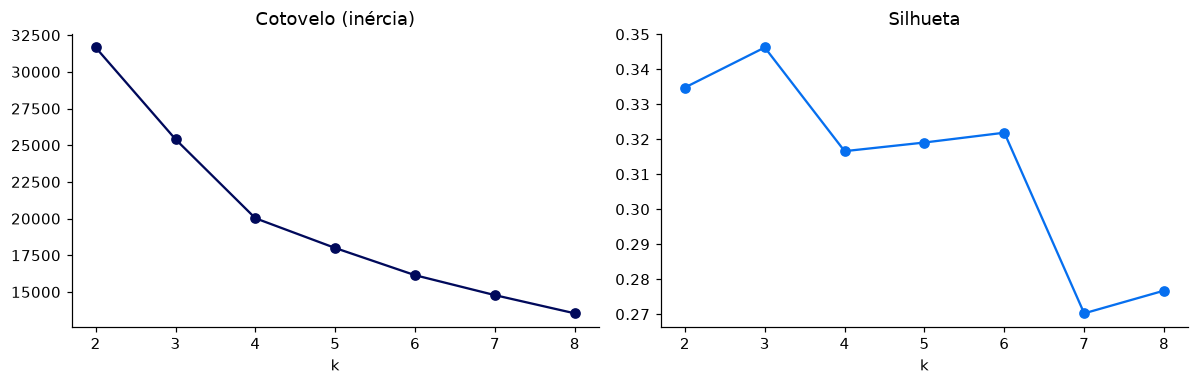

Silhueta por k: {2: 0.335, 3: 0.346, 4: 0.317, 5: 0.319, 6: 0.322, 7: 0.27, 8: 0.277}
Alternativa: hierárquico (Ward, k=4) silhueta 0.302 vs K-Means k=4 0.317


In [13]:
COMPORTAMENTO = ["aderencia_rede", "meses_sem_servico_rede", "meses_sem_servico", "os_por_ano", "ticket_medio", "nps"]


def comportamento(x):
    # K-Means usa distância: o "nunca" (72 meses) puxaria um cluster só para ele. Acima de 3 anos
    # sem serviço, o comportamento é o mesmo para o negócio, então os meses são limitados a 36.
    c = x[COMPORTAMENTO].copy()
    c[["meses_sem_servico_rede", "meses_sem_servico"]] = c[["meses_sem_servico_rede", "meses_sem_servico"]].clip(upper=36)
    return c


segmentacao = Pipeline([("imputar", SimpleImputer(strategy="median")), ("padronizar", StandardScaler())])
Z = segmentacao.fit_transform(comportamento(X))
amostra = np.random.default_rng(SEMENTE).choice(len(Z), size=3000, replace=False)

inercias, silhuetas = {}, {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEMENTE).fit(Z)
    inercias[k] = km.inertia_
    silhuetas[k] = silhouette_score(Z[amostra], km.labels_[amostra])

fig, eixos = plt.subplots(1, 2, figsize=(11, 3.6))
eixos[0].plot(list(inercias), list(inercias.values()), "o-", color=AZUL_FORD)
eixos[0].set(title="Cotovelo (inércia)", xlabel="k")
eixos[1].plot(list(silhuetas), list(silhuetas.values()), "o-", color=AZUL_DESTAQUE)
eixos[1].set(title="Silhueta", xlabel="k")
plt.tight_layout()
plt.show()

hierarquico = AgglomerativeClustering(n_clusters=4, linkage="ward").fit(Z[amostra])
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=SEMENTE).fit(Z)
print("Silhueta por k:", {k: round(v, 3) for k, v in silhuetas.items()})
print(f"Alternativa: hierárquico (Ward, k=4) silhueta {silhouette_score(Z[amostra], hierarquico.labels_):.3f} "
      f"vs K-Means k=4 {silhuetas[4]:.3f}")

### 6.1 Rótulos de negócio

Cada cluster recebe o rótulo de negócio cujo comportamento típico mais se parece com o seu centroide. A atribuição é feita de uma vez para os quatro (algoritmo húngaro), para dois clusters não receberem o mesmo nome:

- **Fiel**: aderência alta e serviço recente na rede;
- **Abandono**: aderência baixa e muito tempo sem a rede;
- **Esquecido**: muito tempo sem *nenhum* serviço e baixa frequência;
- **Econômico**: ticket baixo e alta frequência (faz muitos serviços simples, parte fora da rede).

In [14]:
centroides = pd.DataFrame(kmeans.cluster_centers_, columns=COMPORTAMENTO)  # já padronizados
assinaturas = {
    "FIEL": centroides["aderencia_rede"] - centroides["meses_sem_servico_rede"],
    "ABANDONO": -centroides["aderencia_rede"] + centroides["meses_sem_servico_rede"] - centroides["meses_sem_servico"],
    "ESQUECIDO": centroides["meses_sem_servico"] - centroides["os_por_ano"],
    "ECONOMICO": -centroides["ticket_medio"] + centroides["os_por_ano"],
}
rotulos = list(assinaturas)
afinidade = np.array([assinaturas[r].to_numpy() for r in rotulos])        # rótulo x cluster
linhas_ix, colunas_ix = linear_sum_assignment(-afinidade)
ROTULO_DO_CLUSTER = {int(c): rotulos[r] for r, c in zip(linhas_ix, colunas_ix)}

base["perfil_kmeans"] = pd.Series(kmeans.labels_).map(ROTULO_DO_CLUSTER).to_numpy()
resumo_clusters = (comportamento(X).assign(perfil=base["perfil_kmeans"], evadiu=y)
                   .groupby("perfil").agg(["mean"]).round(2))
resumo_clusters.columns = [c[0] for c in resumo_clusters.columns]
resumo_clusters["tamanho_%"] = (base["perfil_kmeans"].value_counts(normalize=True) * 100).round(1)
display(resumo_clusters)
ARI = adjusted_rand_score(base["perfil_oculto"], base["perfil_kmeans"])
print(f"Índice de Rand ajustado contra o perfil oculto: {ARI:.3f} (1 = recuperação perfeita, 0 = acaso)")
pd.crosstab(base["perfil_oculto"], base["perfil_kmeans"], normalize="index").round(2)

,aderencia_rede,meses_sem_servico_rede,meses_sem_servico,os_por_ano,ticket_medio,nps,evadiu,tamanho_%
perfil,,,,,,,,
ABANDONO,0.16,33.46,4.67,1.69,1115.11,5.31,0.86,19.8
ECONOMICO,0.62,6.46,3.72,2.52,803.26,7.30,0.19,26.9
ESQUECIDO,0.39,31.56,28.96,0.55,1336.37,6.90,0.65,20.7
FIEL,0.91,7.24,4.54,1.76,1544.59,8.62,0.06,32.6


Índice de Rand ajustado contra o perfil oculto: 0.705 (1 = recuperação perfeita, 0 = acaso)


perfil_kmeans,ABANDONO,ECONOMICO,ESQUECIDO,FIEL
perfil_oculto,,,,
ABANDONO,0.91,0.02,0.05,0.02
ECONOMICO,0.05,0.90,0.03,0.02
ESQUECIDO,0.02,0.01,0.89,0.07
FIEL,0.01,0.11,0.04,0.85


## 7. Aplicação na frota da demonstração (deploy em lote)

A frota da massa de demonstração da API é exportada do MySQL por `exportar_frota.sql` (só dados do veículo e do relacionamento, sem dados pessoais). O modelo final e o K-Means são aplicados a ela, e cada veículo vira uma linha no formato do `POST /api/v1/leads`:

| Campo da API | Origem |
|---|---|
| `score` | Probabilidade de evasão do modelo final |
| `prioridade` | Faixa do score: CRITICA (≥ 0,85), ALTA (≥ 0,70), MEDIA (≥ 0,40), BAIXA |
| `perfilComportamental` | Rótulo do cluster do K-Means |
| `motivo` | Os dois fatores de risco mais fortes presentes no veículo, em linguagem de negócio |
| `acaoRecomendada` | Ação padrão do perfil |

Só viram lead os veículos com score acima do **limiar de decisão** do modelo. Clientes sem consentimento LGPD são enviados mesmo assim, porque a própria API registra o lead já **suprimido** (`LGPD_OPT_OUT`) e ele nunca aparece na fila: a regra de privacidade fica num lugar só.

In [15]:
caminho_local = PASTA / "dados" / "frota_demo.csv"
frota = pd.read_csv(caminho_local if caminho_local.exists() else URL_FROTA)
X_frota = preparar(frota)
frota["score"] = modelo_final.predict_proba(X_frota)[:, 1].round(2)
frota["perfil"] = pd.Series(kmeans.predict(segmentacao.transform(comportamento(X_frota)))).map(ROTULO_DO_CLUSTER)


def prioridade(score):
    return "CRITICA" if score >= 0.85 else "ALTA" if score >= 0.70 else "MEDIA" if score >= 0.40 else "BAIXA"


def motivo(linha):
    """Fatores de risco presentes, do mais forte para o mais fraco, em texto para o consultor."""
    fatores = []
    if linha["meses_sem_servico_rede"] >= 72:
        fatores.append("Nunca fez serviço na rede")
    elif linha["meses_sem_servico_rede"] >= 12:
        fatores.append(f"Sem serviço na rede há {linha['meses_sem_servico_rede']:.0f} meses")
    if linha["garantia_vencida"]:
        fatores.append(f"Garantia encerrada há {-linha['meses_garantia']:.0f} meses")
    if linha["os_total"] and linha["aderencia_rede"] < 0.5:
        fatores.append(f"Só {linha['aderencia_rede']:.0%} dos serviços na rede")
    if linha["revisao_vencida"]:
        fatores.append("Revisão vencida")
    if pd.notna(linha["nps"]) and linha["nps"] <= 6:
        fatores.append(f"NPS {linha['nps']:.0f}")
    if linha["qtd_falhas"]:
        fatores.append("Alerta de falha na telemetria")
    return "; ".join(fatores[:2]) if fatores else "Score do modelo acima do limiar"


ACAO = {
    "FIEL": "Lembrar a próxima revisão e oferecer agendamento direto",
    "ABANDONO": "Ligar oferecendo diagnóstico gratuito e condição especial de retorno",
    "ESQUECIDO": "Avisar a revisão pendente e oferecer horário nesta semana",
    "ECONOMICO": "Oferecer revisão com preço fechado Ford",
}

leads = pd.DataFrame({
    "veiculoId": frota["veiculo_id"], "clienteId": frota["cliente_id"], "vin": frota["vin"],
    "score": frota["score"], "prioridade": frota["score"].map(prioridade),
    "motivo": X_frota.apply(motivo, axis=1), "acaoRecomendada": frota["perfil"].map(ACAO),
    "perfilComportamental": frota["perfil"], "consentimentoAtivo": frota["consentimento_ativo"],
    "geraLead": (frota["score"] >= round(LIMIAR, 2)).astype(int),
}).sort_values("score", ascending=False)
leads.to_csv(SAIDA / "leads_modelo.csv", index=False, encoding="utf-8-sig")
print(f"{len(leads)} veículos pontuados | {leads['geraLead'].sum()} acima do limiar ({LIMIAR:.2f}) viram lead")
print("Perfis na frota:", leads["perfilComportamental"].value_counts().to_dict())
leads.head(12)

37 veículos pontuados | 9 acima do limiar (0.57) viram lead
Perfis na frota: {'FIEL': 22, 'ECONOMICO': 10, 'ABANDONO': 5}


,veiculoId,clienteId,vin,score,prioridade,motivo,acaoRecomendada,perfilComportamental,consentimentoAtivo,geraLead
34,35,28,9BFXD482HMSVRCSB5,0.87,CRITICA,Nunca fez serviço na rede; Garantia encerrada ...,Ligar oferecendo diagnóstico gratuito e condiç...,ABANDONO,1,1
26,27,22,9BFT00B0KB1763PS7,0.84,ALTA,Nunca fez serviço na rede; Garantia encerrada ...,Ligar oferecendo diagnóstico gratuito e condiç...,ABANDONO,1,1
2,3,3,9BFRHMLMFR0P96DF3,0.80,ALTA,Nunca fez serviço na rede; Garantia encerrada ...,Ligar oferecendo diagnóstico gratuito e condiç...,ABANDONO,1,1
9,10,8,9BFTD9B1FS40TRG00,0.76,ALTA,Sem serviço na rede há 14 meses; Garantia ence...,Lembrar a próxima revisão e oferecer agendamen...,FIEL,1,1
17,18,15,9BFXHTGW35KR85BT8,0.64,MEDIA,Garantia encerrada há 38 meses; Revisão vencida,Oferecer revisão com preço fechado Ford,ECONOMICO,1,1
25,26,21,9BF18BGFS90D2PB66,0.63,MEDIA,Garantia encerrada há 35 meses; Só 40% dos ser...,Lembrar a próxima revisão e oferecer agendamen...,FIEL,1,1
18,19,16,9BFXR3MJLVF4SB8T9,0.62,MEDIA,Sem serviço na rede há 15 meses; Garantia ence...,Oferecer revisão com preço fechado Ford,ECONOMICO,1,1
19,20,16,9BFMN8KNKB5512FV0,0.60,MEDIA,Garantia encerrada há 17 meses; Revisão vencida,Oferecer revisão com preço fechado Ford,ECONOMICO,1,1
6,7,6,9BFB384GY4WZJDPH7,0.59,MEDIA,Nunca fez serviço na rede; Só 0% dos serviços ...,Ligar oferecendo diagnóstico gratuito e condiç...,ABANDONO,1,1
3,4,4,9BFJKD4NL04BHG2Z4,0.56,MEDIA,Garantia encerrada há 13 meses; Revisão vencida,Lembrar a próxima revisão e oferecer agendamen...,FIEL,1,0


Para enviar os leads à API rodando localmente (perfil ADMIN, que é a conta de serviço da camada de inteligência):

```powershell
powershell -ExecutionPolicy Bypass -File ml\importar-leads.ps1
```

O script lê `saida/leads_modelo.csv`, ignora veículos que já têm lead aberto na fila e faz um `POST /api/v1/leads` para cada um dos demais com `geraLead = 1`.

## 8. Conclusão

In [16]:
f = comparacao.loc[metricas_finais["modelo"]]
print(f"Modelo final: {NOME_FINAL}")
print(f"Teste -> recall {f['recall']:.1%} | precisão {f['precisao']:.1%} | ROC-AUC {f['roc_auc']:.3f} | PR-AUC {f['pr_auc']:.3f}")
print(f"Limiar de decisão: {LIMIAR:.3f}")
print(f"Contatando os 30% de maior score: {CAPTURA_30:.0%} das evasões encontradas")
print(f"Segmentação: K-Means k={K}, ARI contra o perfil oculto {ARI:.3f}")

Modelo final: Regressão Logística
Teste -> recall 78.8% | precisão 78.7% | ROC-AUC 0.903 | PR-AUC 0.839
Limiar de decisão: 0.566
Contatando os 30% de maior score: 66% das evasões encontradas
Segmentação: K-Means k=4, ARI contra o perfil oculto 0.705


### Modelo selecionado: Regressão Logística

Regularização `C ≈ 0,083`, `class_weight="balanced"` e limiar de decisão **0,566** (recall de 80% na validação).

**Justificativa da escolha**

- **Empate técnico, desempate pelo critério de negócio.** Na validação cruzada, os quatro algoritmos ficaram com PR-AUC entre 0,847 e 0,862, com desvios entre dobras (cerca de ±0,015) que se sobrepõem. A Regressão Logística teve a maior PR-AUC e ROC-AUC na validação e no teste, e a melhor precisão com recall de pelo menos 80%, que é a regra definida na seção 1.
- **Interpretabilidade.** Cada coeficiente é um efeito explicável ao gerente da concessionária, o que sustenta o campo `motivo` de cada lead.
- **Custo de inferência mínimo.** Pontuar a frota inteira é um produto escalar por veículo: segundos para milhões de VINs, sem GPU e com deploy simples.
- **O que o empate diz sobre os dados.** Os efeitos na base são majoritariamente aditivos, e Random Forest e Gradient Boosting não encontraram interações que compensassem a complexidade. Com dados reais, a comparação deve ser refeita; o pipeline já está pronto para isso.

**Principais resultados (conjunto de teste, 1.600 veículos nunca vistos)**

| Métrica | Valor |
|---|---|
| Recall da classe "evadiu" | 78,8% |
| Precisão | 78,7% |
| ROC-AUC | 0,903 |
| PR-AUC | 0,84 |
| Evasões encontradas contatando os 30% de maior score | 66% (ao acaso: 30%) |

As variáveis que mais pesam no score são **tempo sem serviço na rede**, **revisão vencida**, **NPS**, **aderência à rede** e **garantia encerrada**.

**Segmentação.** K-Means com k = 4: silhueta de 0,317. A silhueta com k = 3 é um pouco maior (0,346), mas funde perfis que pedem ações de negócio diferentes; k = 4 fica próximo dos melhores valores e recupera os quatro perfis com 85% a 91% de acerto cada um (índice de Rand ajustado 0,705). O hierárquico (Ward) com k = 4 ficou abaixo (silhueta 0,302).

### Como o modelo é usado na aplicação

```
MySQL da API ──exportar_frota.sql──► frota_demo.csv ──notebook──► leads_modelo.csv
      ▲                                                                │
      │                                                   importar-leads.ps1
      │                                                                ▼
 app do consultor ◄── fila ordenada por score ◄── API Java: POST /api/v1/leads (ADMIN)
      │                                            supressão LGPD automática
      └── desfecho de cada contato ──► tabela desfechos_lead ──► rótulos reais para o retreino
```

- **MVP (implementado): deploy em lote.** O notebook pontua a frota exportada do banco, e o script `importar-leads.ps1` cria os leads pela API com a conta ADMIN, que é a conta de serviço da camada de inteligência. A API aplica a supressão LGPD e ordena a fila por score, e o consultor vê o lead no app com motivo, ação recomendada e perfil.
- **Produção (próximo passo).** Um job diário com o modelo serializado (`joblib`) num serviço de inferência Python (FastAPI) atrás do mesmo gateway; versionamento de modelos em registro (MLflow); monitoramento de *drift* das variáveis (PSI) com alerta para retreino.
- **Realimentação.** Cada desfecho registrado no app (agendado, recusado, sem sucesso) fica gravado com autor e data. Esses são os rótulos reais que substituem a base sintética no retreino.

### Limitações e trabalhos futuros

- **Base de treino sintética.** As métricas mostram que o pipeline funciona de ponta a ponta, não o desempenho real na rede Ford. A primeira melhoria é treinar com o histórico real de ordens de serviço (DMS) e a telemetria do FordPass Connect.
- **Calibração.** Aplicar `CalibratedClassifierCV` para que o score possa ser lido diretamente como probabilidade.
- **Explicação por lead.** Trocar as regras do campo `motivo` por contribuições individuais (SHAP).
- **Janela e tempo até a evasão.** Testar outras janelas além de 12 meses e modelos de sobrevivência.
- **Uplift.** Priorizar quem *responde* ao contato, e não só quem tem risco de sair.